In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import requests
from astropy.io import fits
from bs4 import BeautifulSoup
from tqdm import tqdm
from astropy.visualization import ZScaleInterval
from matplotlib import colors

In [2]:
# Find the files in the server
local_path = '/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/'
path = 'https://simulations.sdc.leibniz-kis.de/opendap/co5bold/'
base = ''.join([path, 'SVGd3r05bn0cp1p/'])

# Define directories for different magnetic field strengths
hx = ["SVGd3r17bh1cp1p/", "SVGd3r15bh5cp1p/", "SVGd3r16bhCcp1p/"]
vx = ["SVGd3r12bv1cp1p/", "SVGd3r09bv5cp1p/", "SVGd3r13bvCcp1p/"]
z0 = ["SVGd3r05bn0cp1p/"]

# Create full paths
base_hx = [path + s for s in hx]  # horizontal magnetic field; 10G, 50G, 100G
base_vx = [path + s for s in vx]  # vertical magnetic field; 10G, 50G, 100G
base_z0 = [path + s for s in z0]  # non-magnetic

# Define empty lists to store data for all directories
# Empty lists to store data
vz_hx = np.zeros((len(base_hx), 482//2, 120, 480, 480))
t_hx  = np.zeros((len(base_hx), 482//2))

# Loop over all directories
for j, base in enumerate(base_hx):

    # Fetch directory HTML
    html = requests.get(base).text
    soup = BeautifulSoup(html, 'html.parser')

    # Only keep links that end exactly in .h5
    files = [base + a['href'] for a in soup.find_all('a') if a.get('href', '').endswith('.h5')]

    # Split file name from path
    file_names = [base + f.split('/')[-1] for f in files]
    
    # Add filenames to a text file
    with open(''.join([local_path, 'hx/file_names_hx_', str(j), '.txt']), 'w') as f:
        for item in file_names:
            f.write("%s\n" % item)

# Loop over all base_vx
for j, base in enumerate(base_vx):

    # Fetch directory HTML
    html = requests.get(base).text
    soup = BeautifulSoup(html, 'html.parser')

    # Only keep links that end exactly in .h5
    files = [base + a['href'] for a in soup.find_all('a') if a.get('href', '').endswith('.h5')]

    # Split file name from path
    file_names = [base + f.split('/')[-1] for f in files]
    
    # Add filenames to a text file
    with open(''.join([local_path, 'vx/file_names_vx_', str(j), '.txt']), 'w') as f:
        for item in file_names:
            f.write("%s\n" % item)

# Loop over all base_z0
for j, base in enumerate(base_z0):

    # Fetch directory HTML
    html = requests.get(base).text
    soup = BeautifulSoup(html, 'html.parser')

    # Only keep links that end exactly in .h5
    files = [base + a['href'] for a in soup.find_all('a') if a.get('href', '').endswith('.h5')]

    # Split file name from path
    file_names = [base + f.split('/')[-1] for f in files]
    
    # Add filenames to a text file
    with open(''.join([local_path, 'z0/file_names_z0_', str(j), '.txt']), 'w') as f:
        for item in file_names:
            f.write("%s\n" % item)

In [2]:
# Download the server data as an example
server_data = xr.open_dataset('/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx/10G/simulations.sdc.leibniz-kis.de_opendap_co5bold_SVGd3r17bh1cp1p_rhd_t00033600s.h5_subset.nc', decode_times=False)
server_data

<xarray.Dataset> Size: 19MB
Dimensions:  (xc3: 6, xc2: 240, xc1: 240, xc3b: 6, xb1: 241, xb2: 241, xb3: 7)
Coordinates:
  * xc3      (xc3) float64 48B 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
  * xc2      (xc2) float64 2kB 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
  * xc1      (xc1) float64 2kB 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
  * xc3b     (xc3b) float64 48B 1.59e+08 1.81e+08 2.03e+08 ... 2.47e+08 2.69e+08
  * xb1      (xb1) float32 964B 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
  * xb2      (xb2) float32 964B 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
  * xb3      (xb3) float32 28B 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
Data variables:
    bb1      (xc3, xc2, xc1) float64 3MB ...
    bb2      (xc3, xc2, xc1) float64 3MB ...
    bb3      (xc3, xc2, xc1) float64 3MB ...
    ei       (xc3, xc2, xc1) float64 3MB ...
    v1       (xc3, xc2, xc1) float64 3MB ...
    v2       (xc3, xc2, xc1) float64 3MB ...
    v3       (xc3, xc2, xc1) float64 3MB ...
    rho      (xc3b) float64 48B ...
Attributes: (12/16)
    time:                       33600.355
    time_db:                    33600.35373006761
    itime:                      133458
    Model:                      SVGd3r17bh1cp1p
    SOLMETA_PROJECT:            CO5BOLD Waves Study
    SOLMETA_OBSRVTRY:           Institute of Solar Physics
    ...                         ...
    Description:                CO5BOLD magnetohydrodynamic (MHD) simulation ...
    Reference:                  2021RSPTA.37900177V
    ModelRefName:               Sun-h10
    NCO:                        netCDF Operators version 5.3.6 (Homepage = ht...
    history:                    Fri Jan 16 10:47:08 2026: ncks -A -v rho /Use...
    history_of_appended_files:  Fri Jan 16 10:47:08 2026: Appended file /User...

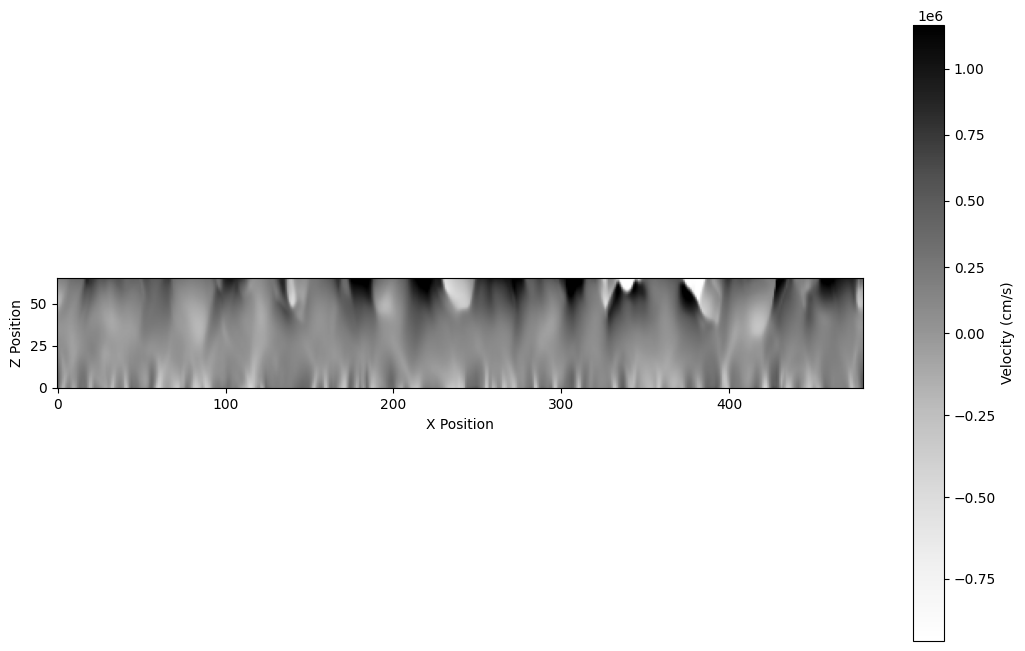

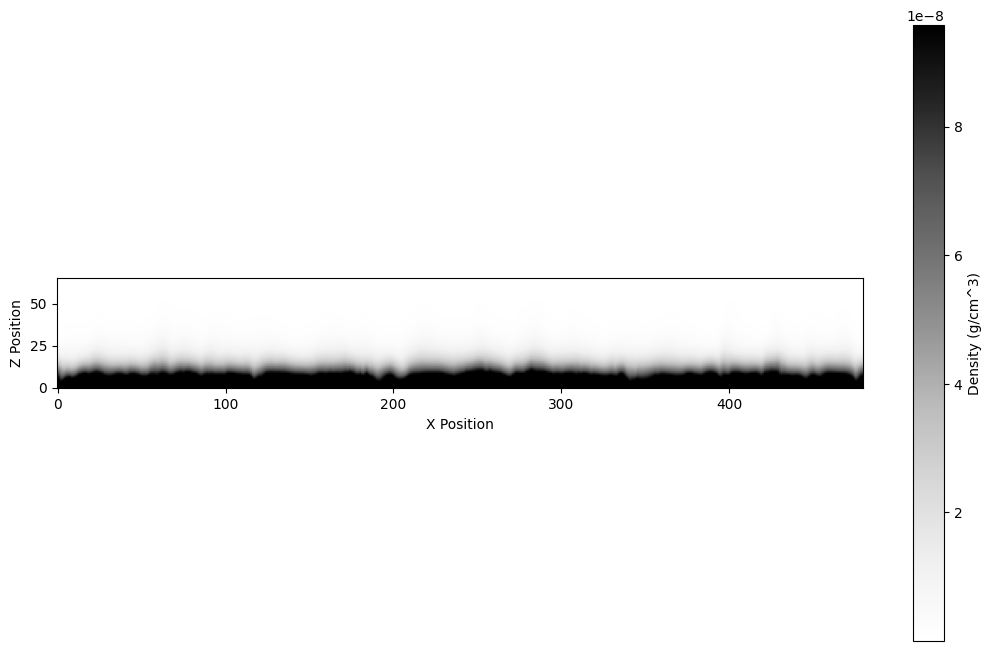

In [4]:
# Take the corrdinates
xc1_server = server_data['xc1'].values
v3_server  = server_data['v3'].values

interval = ZScaleInterval()
vmin, vmax = interval.get_limits(v3_server[:, -1, :])
norm = colors.TwoSlopeNorm(vmin = vmin, vcenter = 0, vmax = vmax)

# Plot the slice of vz at the first time step
plt.figure(figsize=(13, 8))
plt.imshow(v3_server[54:, -1, :], norm = norm, cmap='Grays')
plt.colorbar(label='Velocity (cm/s)')
plt.gca().invert_yaxis()
plt.xlabel('X Position')
plt.ylabel('Z Position')
plt.show()

bz = server_data['rho'][54:, -1, :]
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(bz)
plt.figure(figsize=(13, 8))
plt.imshow(bz, vmin = vmin, vmax = vmax, cmap='Grays')
plt.colorbar(label='Density (g/cm^3)')
plt.gca().invert_yaxis()
plt.xlabel('X Position')
plt.ylabel('Z Position')
plt.show()

In [5]:
# Open the file and check that it worked
data = xr.open_dataset('/Users/juliomorales/Downloads/rhd_t00011970s_subset.nc', engine='h5netcdf')
data
# # Download the vz("v3)" component of velocity on a z slice at index=54
# v3 = np.array(data["v3"])  # the first dimension here is time

# # Plot the slice of vz at the first time step
# plt.imshow(v3[5, :, :], cmap='RdBu_r')
# plt.colorbar(label='Velocity (cm/s)')
# plt.xlabel('X Position')
# plt.ylabel('Y Position')
# plt.show()

<xarray.Dataset> Size: 11MB
Dimensions:  (xc3: 6, xc2: 240, xc1: 240, xb1: 241, xb2: 241, xb3: 7)
Coordinates:
  * xc3      (xc3) float64 48B 1.59e+08 1.81e+08 2.03e+08 ... 2.47e+08 2.69e+08
  * xc2      (xc2) float64 2kB 8e+06 2.4e+07 4e+07 ... 3.816e+09 3.832e+09
  * xc1      (xc1) float64 2kB 8e+06 2.4e+07 4e+07 ... 3.816e+09 3.832e+09
  * xb1      (xb1) float32 964B 0.0 1.6e+07 3.2e+07 ... 3.824e+09 3.84e+09
  * xb2      (xb2) float32 964B 0.0 1.6e+07 3.2e+07 ... 3.824e+09 3.84e+09
  * xb3      (xb3) float32 28B 1.48e+08 1.7e+08 1.92e+08 ... 2.58e+08 2.8e+08
Data variables:
    ei       (xc3, xc2, xc1) float64 3MB ...
    rho      (xc3) float64 48B ...
    v1       (xc3, xc2, xc1) float64 3MB ...
    v2       (xc3, xc2, xc1) float64 3MB ...
    v3       (xc3, xc2, xc1) float64 3MB ...
Attributes: (12/16)
    time:                       11970.219
    time_db:                    11970.219155550003
    itime:                      54059
    Model:                      SVGd3r01bnncpp3
    SOLMETA_PROJECT:            CO5BOLD Waves Study
    SOLMETA_OBSRVTRY:           Institute of Solar Physics
    ...                         ...
    Description:                CO5BOLD magnetohydrodynamic (HD) simulation -...
    Reference:                  2017ApJ...835..148V
    ModelRefName:               Non-magnetic
    history:                    Thu Jan 15 14:46:06 2026: ncks -O -4 -L 4 /Us...
    NCO:                        netCDF Operators version 5.3.6 (Homepage = ht...
    history_of_appended_files:  Thu Jan 15 14:46:06 2026: Appended file /User...

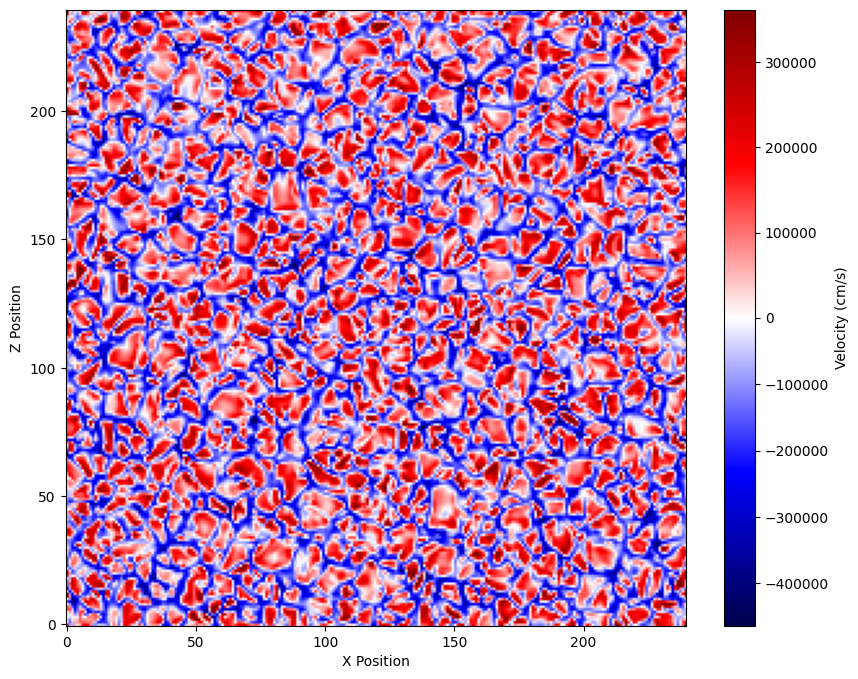

In [6]:
v3_sub = (data['v3'].values)[0, :, :]

interval = ZScaleInterval()
vmin, vmax = interval.get_limits(v3_sub)
norm = colors.TwoSlopeNorm(vmin = vmin, vcenter = 0, vmax = vmax)

# Plot the slice of vz at the first time step
plt.figure(figsize=(10, 8))
plt.imshow(v3_sub, norm = norm, cmap='seismic', aspect = 'auto')
plt.colorbar(label='Velocity (cm/s)')
plt.gca().invert_yaxis()
plt.xlabel('X Position')
plt.ylabel('Z Position')
plt.show()

In [ ]:
# # 2) Run it (example)
# REMOTE_TIMEOUT=600 REMOTE_RETRIES=3 \
# "/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/download_files.sh" \
# "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx/file_names_hx_1.txt" \
# "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx/50G"

In [ ]:
# # 2) Run it (example)
# REMOTE_TIMEOUT=600 REMOTE_RETRIES=3 \
# "/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/download_files.sh" \
# "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx/file_names_hx_2.txt" \
# "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx/100G"

In [ ]:
for d in \
  "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx/10G" \
  "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx/50G" \
  "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/hx/100G"
do
  python3 "/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/Scripts/concatenate_netcdf_time.py" "$d"
done

In [ ]:
# for d in \
#   "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/vx/10G" \
#   "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/vx/50G" \
#   "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/vx/100G"
# do
#   python3 "/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/Scripts/concatenate_netcdf_time.py" "$d"
# done

In [ ]:
# python3 "/Users/juliomorales/Library/CloudStorage/GoogleDrive-juliomorales1823@gmail.com/My Drive/Graduate School/Research/Projects/Helioseismology/Morales_2025a/Code/Scripts/concatenate_netcdf_time.py" "/Users/juliomorales/Research/Projects/Morales_2025a/Data/co5bold/z0/0G/"
